In [2]:
import numpy as np
X = np.array([[0,0], [0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])
w1 = np.random.randn(2,4)*0.01
b1 = np.zeros((1,4))
w2 = np.random.randn(4,1)*0.01
b2 = np.zeros((1,1))
lr = 0.1
epochs = 1000

In [3]:
z1 = np.dot(X, w1) + b1
a1 = np.maximum(0, z1)

z2 = np.dot(a1, w2) + b2
a2 = 1 / (1 + np.exp(-z2))


In [4]:
m = X.shape[0]
loss = -np.sum(y*np.log(a2 +1e-15) + (1-y)*np.log(1-a2 + 1e-15))/m

In [5]:
da2 = -(y / (a2 + 1e-15)) + ((1 - y) / (1 - a2 + 1e-15))
dz2 = da2 * a2 * (1 - a2)
dw2 = np.dot(a1.T, dz2) / m
db2 = np.sum(dz2, axis=0, keepdims=True) / m

da1 = np.dot(dz2, w2.T)
dz1 = da1 * (z1 > 0)
dw1 = np.dot(X.T, dz1) / m
db1 = np.sum(dz1, axis=0, keepdims=True) / m


In [6]:
for epoch in range(epochs):
    z1 = np.dot(X, w1) + b1
    a1 = np.maximum(0, z1)
    z2 = np.dot(a1, w2) + b2
    a2 = 1 / (1 + np.exp(-z2))

    m = X.shape[0]
    loss = -np.sum(y * np.log(a2 + 1e-15) + (1 - y) * np.log(1 - a2 + 1e-15)) / m

    da2 = -(y / (a2 + 1e-15)) + ((1 - y) / (1 - a2 + 1e-15))
    dz2 = da2 * a2 * (1 - a2)
    dw2 = np.dot(a1.T, dz2) / m
    db2 = np.sum(dz2, axis=0, keepdims=True) / m

    da1 = np.dot(dz2, w2.T)
    dz1 = da1 * (z1 > 0)
    dw1 = np.dot(X.T, dz1) / m
    db1 = np.sum(dz1, axis=0, keepdims=True) / m

    w2 -= lr * dw2
    b2 -= lr * db2
    w1 -= lr * dw1
    b1 -= lr * db1

    if epoch % 200 == 0:
        print(f"Epoch {epoch} - Loss: {loss:.4f}")


Epoch 0 - Loss: 0.6931
Epoch 200 - Loss: 0.6929
Epoch 400 - Loss: 0.6884
Epoch 600 - Loss: 0.6088
Epoch 800 - Loss: 0.4152


In [7]:
!pip install numpy matplotlib tensorflow scikit-learn torch torchvision


In [8]:

import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD


In [9]:
class Perceptron:
    def __init__(self, input_size, lr=0.1, epochs=100):
        self.weights = np.zeros(input_size + 1)
        self.lr = lr
        self.epochs = epochs

    def activation(self, x):
        return 1 if x >= 0 else 0

    def predict(self, x):
        z = np.dot(x, self.weights[1:]) + self.weights[0]
        return self.activation(z)

    def fit(self, X, y):
        for _ in range(self.epochs):
            for idx, x_i in enumerate(X):
                prediction = self.predict(x_i)
                update = self.lr * (y[idx] - prediction)
                self.weights[1:] += update * x_i
                self.weights[0] += update


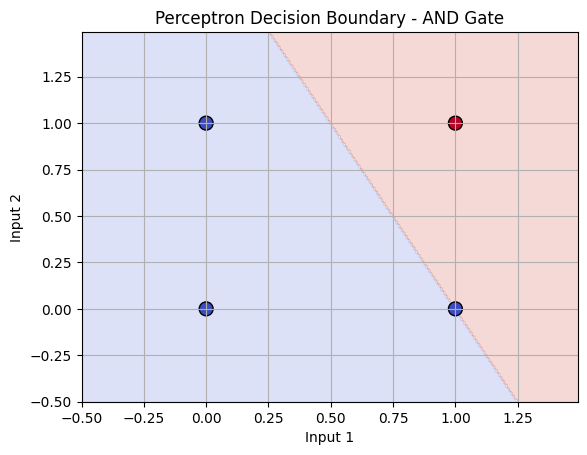

In [11]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 0, 0, 1])

model = Perceptron(input_size=2)
model.fit(X, y)

x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

grid_points = np.c_[xx.ravel(), yy.ravel()]
preds = np.array([model.predict(p) for p in grid_points])
preds = preds.reshape(xx.shape)

plt.contourf(xx, yy, preds, alpha=0.2, cmap='coolwarm')
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=100, cmap='coolwarm')
plt.title("Perceptron Decision Boundary - AND Gate")
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.grid(True)
plt.show()


Multi-Layer Perceptron for Non-linear.

In [12]:
X_xor = np.array([[0,0], [0,1], [1,0], [1,1]])
y_xor = np.array([0, 1, 1, 0])

mlp = Sequential([
    Dense(4, activation='relu', input_shape=(2,)),
    Dense(1, activation='sigmoid')
])

mlp.compile(optimizer=SGD(learning_rate=0.1), loss='binary_crossentropy', metrics=['accuracy'])
history = mlp.fit(X_xor, y_xor, epochs=500, verbose=0)

print(f"Final Model Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Final Model Accuracy: 100.00%


 XOR Space Decision Boundary Rendering


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


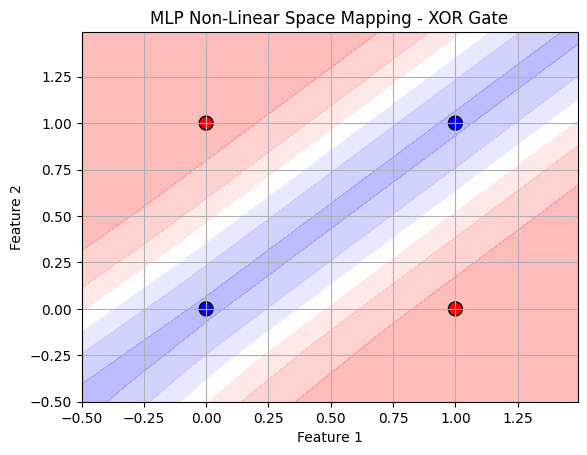

In [13]:
xx_xor, yy_xor = np.meshgrid(np.arange(-0.5, 1.5, 0.01), np.arange(-0.5, 1.5, 0.01))
grid_xor = np.c_[xx_xor.ravel(), yy_xor.ravel()]
preds_xor = mlp.predict(grid_xor)
preds_xor = preds_xor.reshape(xx_xor.shape)

plt.contourf(xx_xor, yy_xor, preds_xor, alpha=0.3, cmap='bwr')
plt.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor, edgecolors='k', s=100, cmap='bwr')
plt.title("MLP Non-Linear Space Mapping - XOR Gate")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()
